In [1]:
import sqlite3
import pandas as pd

In [2]:
db_path="./archive/database.sqlite"
conn=sqlite3.connect(db_path)

In [3]:
tables = pd.read_sql_query("""
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """, conn)

tables

,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


Za potrebe klasterovanja izabrana je tabela Player_Attributes, jer sadrži detaljne numeričke atribute igrača koji opisuju njihove tehničke, fizičke i golmanske karakteristike. Ovakav skup obeležja omogućava prirodno grupisanje igrača prema sličnom stilu igre i ulozi na terenu.

In [4]:
df = pd.read_sql_query("SELECT * FROM Player_Attributes", conn)

conn.close()

print(df.shape)
df.head()

(183978, 42)


,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [5]:
df.isnull().sum().sort_values(ascending=False).head(20)

attacking_work_rate    3230
volleys                2713
agility                2713
sliding_tackle         2713
vision                 2713
jumping                2713
curve                  2713
balance                2713
defensive_work_rate     836
potential               836
shot_power              836
reactions               836
long_shots              836
stamina                 836
overall_rating          836
preferred_foot          836
crossing                836
short_passing           836
long_passing            836
free_kick_accuracy      836
dtype: int64

Izbacujemo identifikatore i neinformativne atribute (id, player_fifa_api_id, player_api_id, date) koji ne nose informaciju o performansama igrača i prave sumove pri klasterovanju.

In [6]:
df = df.drop(columns=[
    'id',
    'player_fifa_api_id',
    'player_api_id',
    'date'
])

Pre brisanja redova sa nedostajućim vrednostima, provereno je da li su one sistematski 
vezane za poziciju igrača. Konkretno, interesuje nas da li golmani imaju nedostajuće 
vrednosti u atributima koji opisuju igru u polju (npr. crossing, finishing, marking, 
sliding_tackle), i obrnuto, da li igrači u polju imaju nedostajuće vrednosti u golmanskim 
atributima (gk_diving, gk_handling). Ako bi ovakva zavisnost postojala, brisanje redova 
sa nedostajućim vrednostima bi sistematski uklonilo čitavu grupu igrača (npr. golmane) 
iz skupa podataka, što bi onemogućilo dalju analizu njihovih profila.

In [7]:
gk_redovi = df[df['gk_reflexes'] > 60]
print("Broj 'golmanskih' redova (gk_reflexes > 60):", len(gk_redovi))
print(gk_redovi[['crossing', 'finishing', 'marking', 'sliding_tackle']].isnull().sum())

Broj 'golmanskih' redova (gk_reflexes > 60): 13573
crossing            0
finishing           0
marking             0
sliding_tackle    136
dtype: int64


In [8]:
ne_gk_redovi = df[df['gk_reflexes'] <= 60]
print(ne_gk_redovi[['gk_diving', 'gk_handling']].isnull().sum())

gk_diving      0
gk_handling    0
dtype: int64


Rezultati pokazuju da golmani gotovo u potpunosti imaju popunjene vrednosti u atributima 
za igru u polju (0 nedostajućih vrednosti za crossing, finishing i marking, a samo 136 
od 13573 golmanskih redova, odnosno približno 1%, nema vrednost za sliding_tackle). 
Slično, igrači u polju imaju popunjene golmanske atribute (0 nedostajućih vrednosti). 
Na osnovu ovoga zaključujemo da nedostajuće vrednosti nisu sistematski povezane sa 
pozicijom igrača, te je brisanje redova sa nedostajućim vrednostima opravdano i ne 
narušava reprezentativnost različitih pozicija u skupu podataka.

In [9]:
print("Broj redova pre brisanja nedostajucih vrednosti:", df.shape[0])

Broj redova pre brisanja nedostajucih vrednosti: 183978


In [10]:
df = df.dropna()

print(df.shape)

(180354, 38)


In [11]:
print("Broj redova nakon brisanja nedostajucih vrednosti:", df.shape[0])

Broj redova nakon brisanja nedostajucih vrednosti: 180354


Pre brisanja redova sa nedostajućim vrednostima skup je sadržao 183978 redova, a nakon 
brisanja 180354, što znači da je izgubljeno 3624 redova, odnosno približno 1.97% ukupnog 
skupa podataka. S obzirom na to da je ranije utvrđeno da nedostajuće vrednosti nisu 
sistematski vezane za poziciju igrača, a gubitak od manje od 2% podataka je zanemarljiv 
u odnosu na ukupnu veličinu skupa, brisanje redova sa nedostajućim vrednostima predstavlja 
opravdan i bezbedan pristup koji ne narušava reprezentativnost skupa podataka.

In [12]:
df['preferred_foot'] = df['preferred_foot'].map({
    'left': 0,
    'right': 1
})

In [13]:
print(df['attacking_work_rate'].unique())
print(df['defensive_work_rate'].unique())

['medium' 'high' 'low' 'None' 'le' 'norm' 'stoc' 'y']
['medium' 'high' 'low' '5' 'ean' 'o' '1' 'ormal' '7' '2' '8' '4' 'tocky'
 '0' '3' '6' '9' 'es']


Provera unikatnih vrednosti u kolonama attacking_work_rate i defensive_work_rate 
pokazuje da, pored očekivanih kategorija (low, medium, high), postoje i brojne 
neispravne vrednosti (npr. 'le', 'norm', 'stoc', '5', 'ormal', 'tocky'), koje 
najverovatnije potiču iz greške prilikom kreiranja originalne baze podataka 
(isečeni ili pogrešno učitani stringovi). Pošto ove vrednosti ne nose smislenu 
informaciju i ne mogu se pouzdano rekonstruisati, redovi koji ih sadrže su izbačeni 
iz skupa podataka.

In [14]:
valid_values = ['low', 'medium', 'high']

df = df[
    df['attacking_work_rate'].isin(valid_values) &
    df['defensive_work_rate'].isin(valid_values)
]

In [15]:
df = pd.get_dummies(
    df,
    columns=['attacking_work_rate', 'defensive_work_rate'],
    dtype=int
)

Pošto su attacking_work_rate i defensive_work_rate kategorijske promenljive bez 
prirodnog uređenja (nominalne), primenjeno je one-hot kodiranje (pd.get_dummies) 
kako bi se transformisale u numerički oblik pogodan za algoritme klasterovanja, 
bez veštačkog uvođenja redosleda kao što bi se desilo prostim mapiranjem u brojeve.

In [16]:
print(df.shape)
df.head()

(176161, 42)


,overall_rating,potential,preferred_foot,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,...,gk_handling,gk_kicking,gk_positioning,gk_reflexes,attacking_work_rate_high,attacking_work_rate_low,attacking_work_rate_medium,defensive_work_rate_high,defensive_work_rate_low,defensive_work_rate_medium
0,67.0,71.0,1,49.0,44.0,71.0,61.0,44.0,51.0,45.0,...,11.0,10.0,8.0,8.0,0,0,1,0,0,1
1,67.0,71.0,1,49.0,44.0,71.0,61.0,44.0,51.0,45.0,...,11.0,10.0,8.0,8.0,0,0,1,0,0,1
2,62.0,66.0,1,49.0,44.0,71.0,61.0,44.0,51.0,45.0,...,11.0,10.0,8.0,8.0,0,0,1,0,0,1
3,61.0,65.0,1,48.0,43.0,70.0,60.0,43.0,50.0,44.0,...,10.0,9.0,7.0,7.0,0,0,1,0,0,1
4,61.0,65.0,1,48.0,43.0,70.0,60.0,43.0,50.0,44.0,...,10.0,9.0,7.0,7.0,0,0,1,0,0,1


In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Pre primene algoritama klasterovanja, potrebno je odrediti optimalan broj grupa ($k$) u podacima. U tu svrhu primenjuju se dve komplementarne tehnike: Elbow metoda (prati se suma kvadratnih odstupanja unutar klastera - SSE) i analiza Silhouette koeficijenta (meri se kompaktnost i separabilnost klastera). S obzirom na računarsku složenost Silhouette koeficijenta, evaluacija ove metrike vrši se na reprezentativnom slučajnom uzorku od 3.000 instanci.

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

In [20]:
inertia = []
sil_scores = []

K = range(2, 11)

n_sample = 3000

if X_scaled.shape[0] > n_sample:
    np.random.seed(19)
    idx = np.random.choice(X_scaled.shape[0], n_sample, replace=False)
    X_sil = X_scaled[idx]
else:
    X_sil = X_scaled

In [21]:
for k in K:
    model = KMeans(n_clusters=k, random_state=19, n_init=10)
    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)

    # silhouette samo na uzorku
    if X_scaled.shape[0] > n_sample:
        sample_labels = model.predict(X_sil)
        sil_scores.append(silhouette_score(X_sil, sample_labels))
    else:
        sil_scores.append(silhouette_score(X_scaled, labels))

Parametar n_init=10 korišćen je kako bi algoritam K-sredina bio pokrenut više puta sa različitim slučajnim početnim centroidima, nakon čega je izabrano rešenje sa najmanjom vrednošću SSE.

In [22]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import matplotlib.patches as mpatches

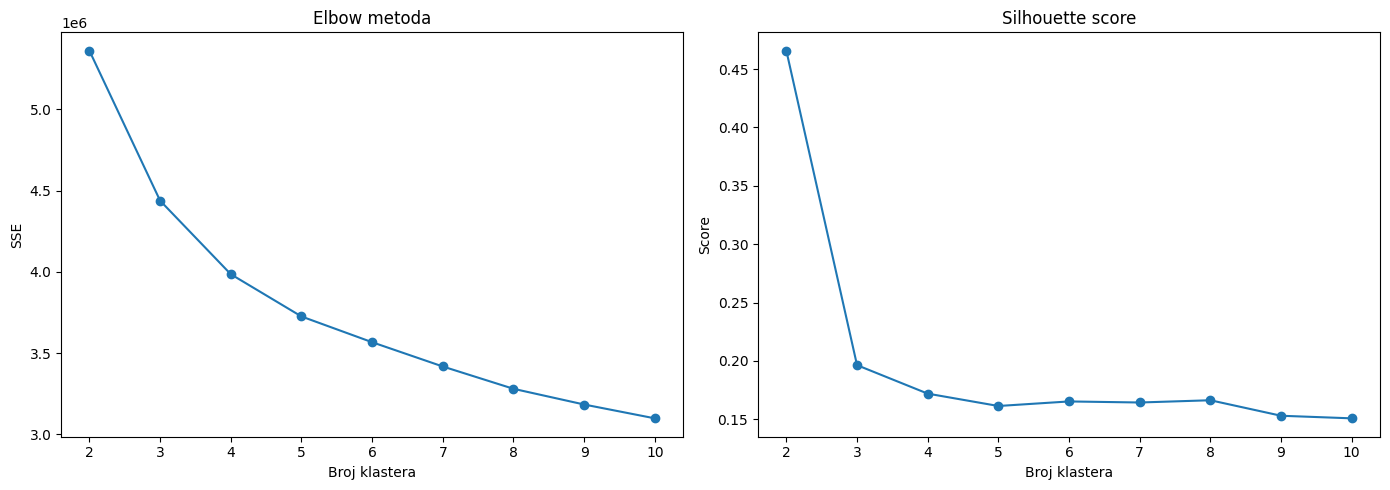

In [23]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.title("Elbow metoda")
plt.xlabel("Broj klastera")
plt.ylabel("SSE")

plt.subplot(1,2,2)
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette score")
plt.xlabel("Broj klastera")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

Na osnovu dobijenog grafika uočeno je da se strmina pada SSE vrednosti smanjuje 
nakon k=4, te ova tačka predstavlja razumnu ravnotežu između broja klastera i 
kompaktnosti modela. Silhouette koeficijent beleži maksimum za k=2, ali vrednosti 
za k=4 do k=8 ostaju u uskom rasponu bez izraženog trenda, pa konačna odluka 
počiva na Elbow metodi i domenskom znanju.

U cilju pronalaženja najstabilnijeg i najinterpretabilnijeg rešenja, nad standardizovanim skupom podataka biće primenjeno pet različitih algoritama klasterovanja, koji se zasnivaju na različitim matematičkim pristupima (particioni, hijerarhijski, gustinski i probabilistički modeli):
1. K-Means (K-sredina) – particioni algoritam zasnovan na minimizaciji unutar-klasterske sume kvadrata udaljenosti.
2. Agglomerative Clustering (Hijerarhijsko klasterovanje) – aglomerativni pristup koji postepeno spaja slične instance.
3. Gaussian Mixture Models (GMM) – probabilistički model koji pretpostavlja da su podaci generisani iz mešavine konačnog broja Gausovih raspodela.
4. BIRCH – hijerarhijski algoritam optimizovan za rad sa velikim skupovima podataka kroz konstrukciju stabla karakteristika klastera.
5. DBSCAN – algoritam zasnovan na gustini koji uspešno identifikuje klastere proizvoljnog oblika i izlučuje šum (outliere).

In [24]:
from sklearn.cluster import KMeans

In [25]:
kmeans = KMeans(n_clusters=4, random_state=19, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

In [26]:
df['KMeans_cluster'] = clusters_kmeans
df[['overall_rating', 'potential', 'KMeans_cluster']].head(10)

,overall_rating,potential,KMeans_cluster
0,67.0,71.0,3
1,67.0,71.0,3
2,62.0,66.0,3
3,61.0,65.0,3
4,61.0,65.0,3
5,74.0,76.0,1
6,74.0,76.0,1
7,73.0,75.0,1
8,73.0,75.0,1
9,73.0,75.0,1


In [27]:
df['KMeans_cluster'].value_counts().sort_index()

KMeans_cluster
0    62153
1    50183
2    14299
3    49526
Name: count, dtype: int64

K-sredina sa 4 klastera formirala je tri velika klastera igrača u polju i jedan značajno manji klaster koji najverovatnije odgovara golmanima.

In [28]:
from sklearn.decomposition import PCA

In [29]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [30]:
print(pca.explained_variance_ratio_)
print("Ukupno sačuvano:", pca.explained_variance_ratio_.sum())

[0.38350528 0.13983574]
Ukupno sačuvano: 0.5233410209228113


Prve dve PCA komponente zajedno objašnjavaju 52.33% ukupne varijanse skupa podataka, 
što znači da 2D prikaz ne zahvata sve strukturne informacije, ali je dovoljno 
indikativan za vizuelnu potvrdu separabilnosti klastera.

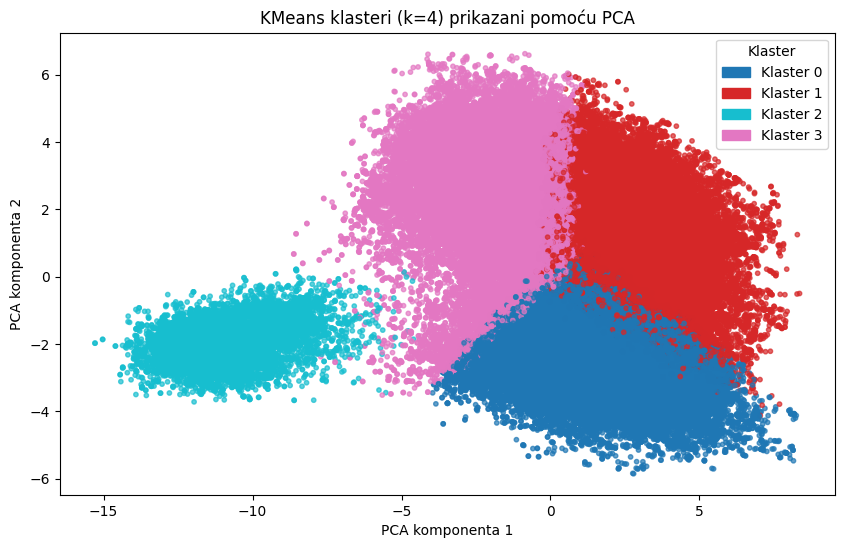

In [31]:
plt.figure(figsize=(10, 6))

colors = ['tab:blue', 'tab:red', 'tab:cyan', 'tab:pink']
cluster_labels = df['KMeans_cluster']

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=[colors[c] for c in cluster_labels],
    s=10,
    alpha=0.7
)

plt.title("KMeans klasteri (k=4) prikazani pomoću PCA")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
patches = [mpatches.Patch(color=colors[i], label=f'Klaster {i}') for i in range(4)]
plt.legend(handles=patches, title="Klaster")
plt.show()

Na PCA 2D prikazu klastera dobijenih algoritmom K-sredina sa 4 klastera uočava se jedna potpuno izdvojena grupa igrača, odgovara golmanima, što potvrđuje tabela prosečnih vrednosti atributa u nastavku. Preostala tri klastera predstavljaju igrače u polju i mogu se interpretirati kao odbrambeni, vezni i napadački profili. Delimično preklapanje u centralnom delu prostora je očekivano zbog sličnosti pojedinih uloga na terenu.

In [32]:
cluster_means = df.groupby('KMeans_cluster').mean()

kljucni_atributi = [
    'overall_rating', 
    'gk_diving', 
    'standing_tackle', 
    'short_passing', 
    'finishing', 
    'sprint_speed'
]

cluster_means[kljucni_atributi].round(2)

,overall_rating,gk_diving,standing_tackle,short_passing,finishing,sprint_speed
KMeans_cluster,,,,,,
0,69.07,9.87,31.83,65.23,66.08,74.53
1,72.77,9.90,68.54,72.97,54.17,71.75
2,68.21,69.88,18.92,28.07,18.16,46.09
3,64.22,9.77,64.22,58.56,34.97,62.82


Tabela prosečnih vrednosti ključnih atributa po klasterima potvrđuje pretpostavku 
o golmanskom klasteru: klaster 2 beleži izrazito visoku prosečnu vrednost gk_diving 
(69.88) uz niske vrednosti finishing (18.16) i standing_tackle (18.92), što jasno 
odgovara golmanskom profilu. Preostala tri klastera odgovaraju igračima u polju sa 
različitim profilima — klaster 0 se ističe visokim finishing vrednostima (66.08) 
što sugeriše napadački profil, klaster 1 ima visok standing_tackle (68.54) što 
upućuje na odbrambene igrače, a klaster 3 pokazuje karakteristike veznih igrača 
sa balansiranim vrednostima.

In [33]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import train_test_split

S obzirom na kvadratnu računarsku složenost algoritma hijerarhijskog klasterovanja, primena na celom skupu nije bila 
izvodljiva. Zbog toga je algoritam primenjen na uzorku od 5000 instanci, uz fiksiran 
seed radi reproducibilnosti rezultata. Kako bi uzorak bio reprezentativan po sastavu 
pozicija igrača, primenjena je stratifikovana podela na osnovu KMeans klastera, čime 
je osigurano da proporcije grupa u uzorku odgovaraju proporcijama u originalnom skupu 
podataka.

In [34]:
_, idx_hc = train_test_split(
    np.arange(X_scaled.shape[0]),
    test_size=5000/X_scaled.shape[0],
    random_state=19,
    stratify=df['KMeans_cluster']
)
X_hc = X_scaled[idx_hc]

In [35]:
hc = AgglomerativeClustering(n_clusters=4)
clusters_hc = hc.fit_predict(X_hc)

In [36]:
X_pca_hc = X_pca[idx_hc]

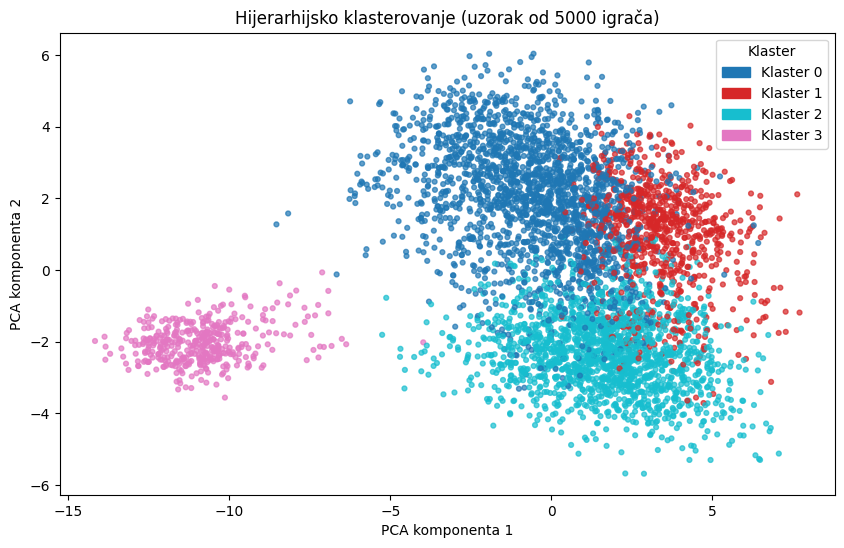

In [37]:
plt.figure(figsize=(10, 6))

colors = ['tab:blue', 'tab:red', 'tab:cyan', 'tab:pink']

plt.scatter(
    X_pca_hc[:, 0],
    X_pca_hc[:, 1],
    c=[colors[c] for c in clusters_hc],
    s=12,
    alpha=0.7
)

plt.title("Hijerarhijsko klasterovanje (uzorak od 5000 igrača)")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
patches = [mpatches.Patch(color=colors[i], label=f'Klaster {i}') for i in range(4)]
plt.legend(handles=patches, title="Klaster")
plt.show()

I K-sredina i hijerarhijsko klasterovanje dosledno izdvajaju jedan mali i jasno separisan klaster, koji odgovara golmanima. Preostala tri klastera predstavljaju igrače u polju, pri čemu hijerarhijski pristup pokazuje nešto veće preklapanje u centralnom delu prostora.

In [38]:
from sklearn.mixture import GaussianMixture

In [39]:
gmm = GaussianMixture(
    n_components=4,
    random_state=19,
    covariance_type='full'
)

clusters_gmm = gmm.fit_predict(X_scaled)

Parametar covariance_type='full' omogućava svakom klasteru sopstvenu kovarijansu, 
što znači da klasteri mogu imati različit oblik, veličinu i orijentaciju u prostoru 
atributa. Za razliku od K-sredine koja pretpostavlja sferične klastere jednake 
veličine, GMM sa punom kovarijansom prilagođava se stvarnoj geometriji podataka, 
što predstavlja jednu od ključnih prednosti ovog pristupa.

In [40]:
df['GMM_cluster'] = clusters_gmm
df['GMM_cluster'].value_counts().sort_index()

GMM_cluster
0    14298
1    93335
2    49853
3    18675
Name: count, dtype: int64

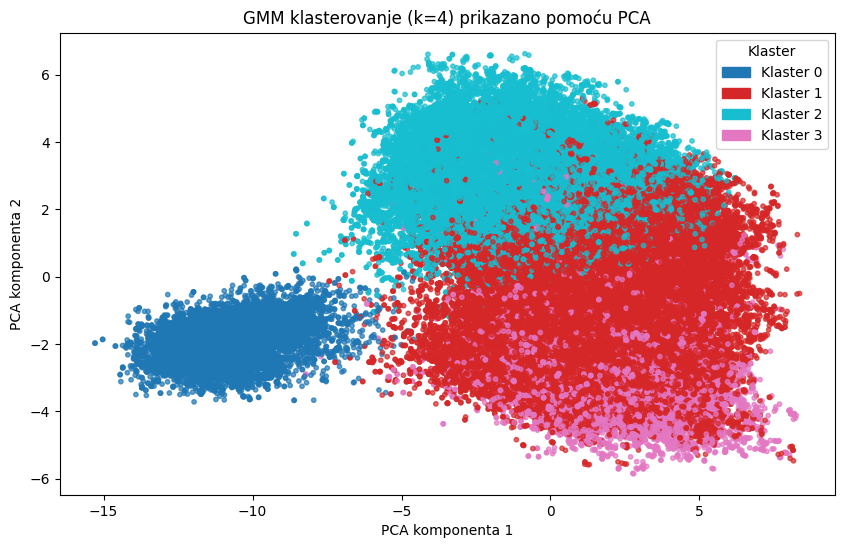

In [41]:
plt.figure(figsize=(10, 6))

colors = ['tab:blue', 'tab:red', 'tab:cyan', 'tab:pink']

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=[colors[c] for c in df['GMM_cluster']],
    s=10,
    alpha=0.7
)

plt.title("GMM klasterovanje (k=4) prikazano pomoću PCA")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
patches = [mpatches.Patch(color=colors[i], label=f'Klaster {i}') for i in range(4)]
plt.legend(handles=patches, title="Klaster")
plt.show()

Za razliku od K-sredina algoritma, GMM pokazuje mekše prelaze između centralnih klastera, što bolje odražava postojanje hibridnih fudbalskih uloga, kao što su ofanzivni vezni ili bekovi sa izraženim napadačkim karakteristikama.

In [42]:
from sklearn.cluster import Birch

In [43]:
for t in [2.0, 2.5, 3.0, 3.5]:
    birch = Birch(n_clusters=None, threshold=t)
    birch.fit(X_scaled)
    print(f"threshold={t} -> broj podklastera: {len(birch.subcluster_centers_)}")

threshold=2.0 -> broj podklastera: 20613
threshold=2.5 -> broj podklastera: 9226
threshold=3.0 -> broj podklastera: 2998
threshold=3.5 -> broj podklastera: 898


Parametar threshold određuje maksimalni prečnik podklastera u BIRCH stablu. 
Manja vrednost daje više podklastera i finiju granulaciju, ali povećava memorijski 
zahtev. Testiranjem više vrednosti odabran je threshold=3.0, koji daje 2998 
podklastera — dovoljno za očuvanje strukture podataka uz prihvatljivu računarsku 
složenost.

In [44]:
birch = Birch(n_clusters=None, threshold=3.0)
birch.fit(X_scaled)

,threshold,3.0
,branching_factor,50
,n_clusters,None
,compute_labels,True
,copy,'deprecated'


Kako bi se podklasteri grupisali u četiri završna klastera, primenjen je algoritam 
K-sredina na centrima dobijenih podklastera, umesto direktno na originalnim podacima. 
Ovakav dvokoračni pristup omogućava da BIRCH izvrši efikasnu kompresiju podataka, 
dok K-sredina pronalazi konačnu strukturu na manjem skupu reprezentativnih tačaka.

In [45]:
kmeans_sub = KMeans(n_clusters=4, random_state=19, n_init=10)
subcluster_labels = kmeans_sub.fit_predict(birch.subcluster_centers_)

In [46]:
subcluster_index_for_each_row = birch.predict(X_scaled)

In [47]:
clusters_birch = subcluster_labels[subcluster_index_for_each_row]

In [48]:
df['Birch_cluster'] = clusters_birch

In [49]:
df['Birch_cluster'].value_counts().sort_index()

Birch_cluster
0    27076
1    14298
2    49887
3    84900
Name: count, dtype: int64

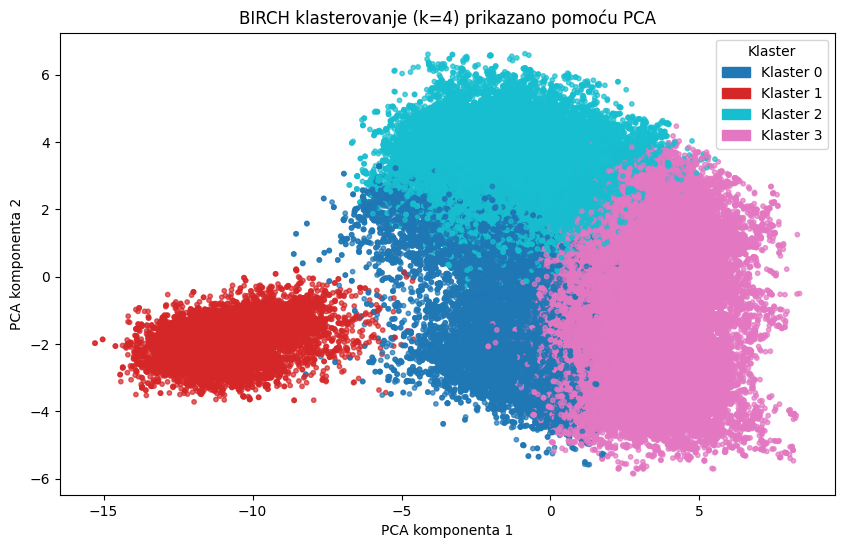

In [50]:
plt.figure(figsize=(10, 6))

colors = ['tab:blue', 'tab:red', 'tab:cyan', 'tab:pink']

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=[colors[c] for c in df['Birch_cluster']],
    s=10,
    alpha=0.7
)

plt.title("BIRCH klasterovanje (k=4) prikazano pomoću PCA")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
patches = [mpatches.Patch(color=colors[i], label=f'Klaster {i}') for i in range(4)]
plt.legend(handles=patches, title="Klaster")
plt.show()

BIRCH daje rezultat veoma sličan algoritmu K-sredina, pri čemu dosledno izdvaja mali i jasno separisan klaster golmana. Ovakvo ponašanje potvrđuje stabilnost strukture podataka i opravdanost izbora 4 klastera.


In [51]:
from sklearn.cluster import DBSCAN

S obzirom na računarsku složenost algoritma DBSCAN (O(n log n) sa indeksiranjem, 
O(n²) u najgorem slučaju), primena na celom skupu nije bila 
efikasna. Zbog toga je algoritam primenjen na nasumičnom uzorku od 5000 instanci 
uz fiksiran seed radi reproducibilnosti.

In [52]:
np.random.seed(19)

n_db = 5000
idx_db = np.random.choice(X_scaled.shape[0], n_db, replace=False)

X_db = X_scaled[idx_db]
X_pca_db = X_pca[idx_db]

In [53]:
for eps in [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_db)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(f"eps={eps}")
    print(f"  broj klastera: {n_clusters}")
    print(f"  broj šum tačaka: {n_noise}")
    print("-" * 30)

eps=2.5
  broj klastera: 13
  broj šum tačaka: 4224
------------------------------
eps=3.0
  broj klastera: 13
  broj šum tačaka: 2323
------------------------------
eps=3.5
  broj klastera: 7
  broj šum tačaka: 999
------------------------------
eps=4.0
  broj klastera: 4
  broj šum tačaka: 407
------------------------------
eps=4.5
  broj klastera: 3
  broj šum tačaka: 142
------------------------------
eps=5.0
  broj klastera: 3
  broj šum tačaka: 47
------------------------------


In [54]:
for eps in [4.1, 4.2, 4.3, 4.4]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_db)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(f"eps={eps}")
    print(f"  broj klastera: {n_clusters}")
    print(f"  broj šum tačaka: {n_noise}")
    print("-" * 30)

eps=4.1
  broj klastera: 4
  broj šum tačaka: 331
------------------------------
eps=4.2
  broj klastera: 4
  broj šum tačaka: 272
------------------------------
eps=4.3
  broj klastera: 3
  broj šum tačaka: 226
------------------------------
eps=4.4
  broj klastera: 3
  broj šum tačaka: 186
------------------------------


Na osnovu pretrage pokazano je da eps=4.2 daje 4 klastera uz minimalan šum, što predstavlja najbolju ravnotežu između broja klastera i količine 
nerazvrstanih podataka. Vrednosti eps=4.3 i više rezultuju gubitkom jednog klastera, 
pa je eps=4.2 usvojen kao optimalan.

In [55]:
dbscan = DBSCAN(eps=4.2, min_samples=10)
clusters_dbscan = dbscan.fit_predict(X_db)

In [56]:
pd.Series(clusters_dbscan).value_counts().sort_index()

-1     272
 0    4181
 1      91
 2     391
 3      65
Name: count, dtype: int64

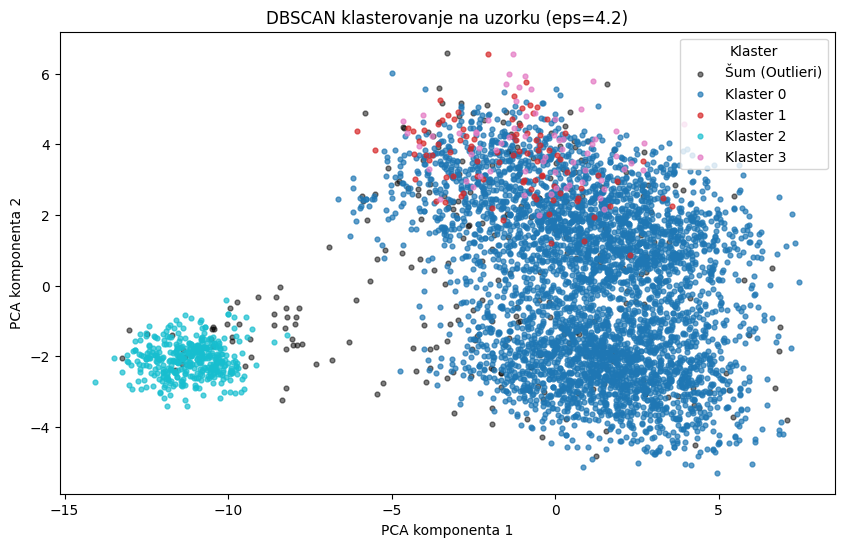

In [57]:
plt.figure(figsize=(10, 6))

colors_db = ['tab:blue', 'tab:red', 'tab:cyan', 'tab:pink']

mask_noise = (clusters_dbscan == -1)
mask_clusters = (clusters_dbscan != -1)

plt.scatter(
    X_pca_db[mask_noise, 0],
    X_pca_db[mask_noise, 1],
    c='black',
    s=12,
    alpha=0.5,
    label='Šum (Outlieri)'
)

cluster_ids = sorted(set(clusters_dbscan[mask_clusters]))
for cid in cluster_ids:
    mask = clusters_dbscan == cid
    plt.scatter(
        X_pca_db[mask, 0],
        X_pca_db[mask, 1],
        c=colors_db[cid], s=12, alpha=0.7, label=f'Klaster {cid}'
    )

plt.title("DBSCAN klasterovanje na uzorku (eps=4.2)")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.legend(loc="upper right", title="Klaster")
plt.show()

Za razliku od prethodnih algoritama, DBSCAN kao algoritam zasnovan na gustini uspešno prepoznaje prirodnu kompaktnost podataka. Sa parametrima $eps=4.2$ i $min\_samples=10$, algoritam jasno izdvaja golmane kao zaseban i homogen Klaster 2, što potvrđuje visoku gustinu ovih profila u prostoru obeležja.Sa druge strane, umesto da veštački podeli preostale igrače u polju na tri ujednačene grupe (kao što su to uradili K-Means i BIRCH), DBSCAN prepoznaje da oni čine jednu masivnu kontinuiranu celinu (Klaster 0). Unutar te celine, algoritam uspeva da locira dva mikro-klastera visoke gustine (Klaster 1 i 3), dok sve igrače sa atipičnim i prelaznim karakteristikama (ukupno 272 instance) ispravno izoluje kao šum (outliere), što je glavna prednost ovog pristupa.

In [58]:
for min_s in [9, 8, 7, 6, 5, 4, 3, 2]:
    dbscan = DBSCAN(eps=4.2, min_samples=min_s)
    labels = dbscan.fit_predict(X_db)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(f"min_samples={min_s}")
    print(f"  broj klastera: {n_clusters}")
    print(f"  broj šum tačaka: {n_noise}")
    print("-" * 30)

min_samples=9
  broj klastera: 4
  broj šum tačaka: 259
------------------------------
min_samples=8
  broj klastera: 4
  broj šum tačaka: 245
------------------------------
min_samples=7
  broj klastera: 5
  broj šum tačaka: 233
------------------------------
min_samples=6
  broj klastera: 5
  broj šum tačaka: 226
------------------------------
min_samples=5
  broj klastera: 3
  broj šum tačaka: 218
------------------------------
min_samples=4
  broj klastera: 5
  broj šum tačaka: 194
------------------------------
min_samples=3
  broj klastera: 4
  broj šum tačaka: 188
------------------------------
min_samples=2
  broj klastera: 21
  broj šum tačaka: 154
------------------------------


Finim podešavanjem parametra min_samples uz fiksirani eps=4.2, utvrđeno je da 
vrednost min_samples=8 daje 4 stabilna klastera uz manji procenat šuma (245 instanci) 
u poređenju sa početnom vrednošću min_samples=10 (272 instance šuma).

In [59]:
dbscan = DBSCAN(eps=4.2, min_samples=8)
clusters_dbscan = dbscan.fit_predict(X_db)

In [60]:
pd.Series(clusters_dbscan).value_counts().sort_index()

-1     245
 0    4189
 1      93
 2     400
 3      73
Name: count, dtype: int64

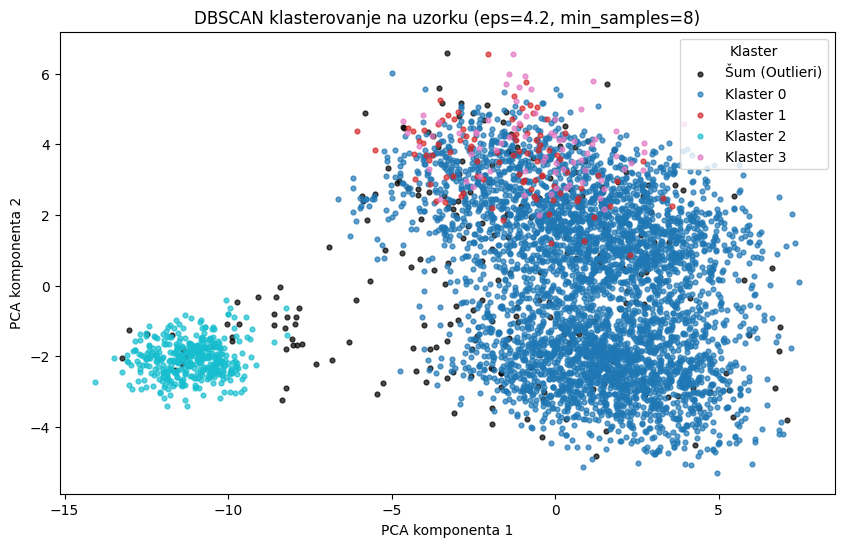

In [61]:
plt.figure(figsize=(10, 6))

colors_db = ['tab:blue', 'tab:red', 'tab:cyan', 'tab:pink']

mask_noise = (clusters_dbscan == -1)
mask_clusters = (clusters_dbscan != -1)

plt.scatter(
    X_pca_db[mask_noise, 0],
    X_pca_db[mask_noise, 1],
    c='black',
    s=12,
    alpha=0.7,
    label='Šum (Outlieri)'
)

cluster_ids = sorted(set(clusters_dbscan[mask_clusters]))
for cid in cluster_ids:
    mask = clusters_dbscan == cid
    plt.scatter(
        X_pca_db[mask, 0],
        X_pca_db[mask, 1],
        c=colors_db[cid], s=12, alpha=0.7, label=f'Klaster {cid}'
    )


plt.title("DBSCAN klasterovanje na uzorku (eps=4.2, min_samples=8)")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.legend(loc="upper right", title="Klaster")
plt.show()

Nakon fiksiranja radijusa na $eps=4.2$, izvršena je dodatna stabilizacija modela finim podešavanjem parametra $min\_samples$. Spuštanjem ove granice sa 10 na 8, uspešno je smanjen procenat izolovanog šuma na svega 245 tačaka. Ova promena je omogućila da se klaster golmana (Klaster 2) proširi na tačno 400 igrača, obuhvatajući i one profile koji se nalaze na samim obodima golmanske specifikacije. Konfiguracija $eps=4.2$ i $min\_samples=8$ usvojena je kao optimalna jer održava strukturu od 4 stabilne grupe, dok istovremeno smanjuje količinu nerazvrstanih podataka.

In [62]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

Zbog velike veličine skupa podataka, metrike kvaliteta klasterovanja računane su nad reprezentativnim slučajnim uzorkom od 5000 instanci.

In [63]:
np.random.seed(19)

n_eval = 5000
idx_eval = np.random.choice(X_scaled.shape[0], n_eval, replace=False)

X_eval = X_scaled[idx_eval]

In [64]:
rezultati = []

# KMeans
labels_kmeans = df["KMeans_cluster"].iloc[idx_eval]
rezultati.append([
    "KMeans",
    silhouette_score(X_eval, labels_kmeans),
    davies_bouldin_score(X_eval, labels_kmeans),
    calinski_harabasz_score(X_eval, labels_kmeans)
])

# GMM
labels_gmm = df["GMM_cluster"].iloc[idx_eval]
rezultati.append([
    "GMM",
    silhouette_score(X_eval, labels_gmm),
    davies_bouldin_score(X_eval, labels_gmm),
    calinski_harabasz_score(X_eval, labels_gmm)
])

# BIRCH
labels_birch = df["Birch_cluster"].iloc[idx_eval]
rezultati.append([
    "BIRCH",
    silhouette_score(X_eval, labels_birch),
    davies_bouldin_score(X_eval, labels_birch),
    calinski_harabasz_score(X_eval, labels_birch)
])

# HC

hc_eval = AgglomerativeClustering(n_clusters=4)
labels_hc = hc_eval.fit_predict(X_eval)

rezultati.append([
    "Hijerarhijsko",
    silhouette_score(X_eval, labels_hc),
    davies_bouldin_score(X_eval, labels_hc),
    calinski_harabasz_score(X_eval, labels_hc)
])

# DBSCAN
dbscan_eval = DBSCAN(eps=4.2, min_samples=8)
labels_dbscan_eval = dbscan_eval.fit_predict(X_eval)

rezultati.append([
    "DBSCAN",
    silhouette_score(X_eval, labels_dbscan_eval),
    davies_bouldin_score(X_eval, labels_dbscan_eval),
    calinski_harabasz_score(X_eval, labels_dbscan_eval)
])

- Silhouette koeficijent (opseg -1 do 1): vrednosti bliže 1 ukazuju na bolje 
  definisane i razdvojene klastere
- Davies-Bouldin indeks (opseg 0 do ∞): niže vrednosti ukazuju na bolju 
  separaciju između klastera
- Calinski-Harabasz indeks: više vrednosti ukazuju na kompaktnije i bolje 
  razdvojene klastere

In [65]:
rez_df = pd.DataFrame(
    rezultati,
    columns=["Algoritam", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
)

rez_df.sort_values("Silhouette", ascending=False)

,Algoritam,Silhouette,Davies-Bouldin,Calinski-Harabasz
4,DBSCAN,0.186682,2.565683,589.576471
0,KMeans,0.174894,1.741409,1497.299749
2,BIRCH,0.156430,1.748373,1371.873276
1,GMM,0.153289,1.924349,1212.063529
3,Hijerarhijsko,0.144116,1.979679,1305.792101


Komparativna analiza metrika kvaliteta sprovedena je na jedinstvenom, geometrijski identičnom uzorku od 5000 igrača, čime je obezbeđena potpuna uporedivost modela. Za razliku od uobičajene prakse gde se šum eliminiše, u ovoj evaluaciji su atipični igrači (outlieri) unutar DBSCAN algoritma zadržani i tretirani kao zasebna grupa, kako bi se dobila realna slika ponašanja modela na celom prostoru obeležja.

Iako **DBSCAN** ostvaruje najvišu vrednost Silhouette koeficijenta (0.186), on beleži izuzetno loš (visok) Davies-Bouldin indeks (2.56). Ovo je direktna posledica činjenice da algoritam, pored uspešnog izolovanja golmana, sve preostale igrače u polju spaja u jedan masivan, nediferenciran klaster, dok čak 245 igrača sa prelaznim karakteristikama označava kao šum. Kada se taj razbacani šum uključi u računicu, geometrijska opravdanost DBSCAN-a značajno opada.

Sa druge strane, **KMeans** se pokazao kao najizbalansiraniji i najefikasniji algoritam za ovaj problem. On ostvaruje visok Silhouette score (0.174), ubedljivo najbolji (najniži) Davies-Bouldin indeks (1.74) i najvišu vrednost Calinski-Harabasz indeksa (1497.30). 

**Zaključak:**
Algoritam **KMeans (sa k=4)** se usvaja kao konačan i optimalan model za klasterovanje fudbalskih performansi. Bez potrebe za odbacivanjem atipičnih podataka, KMeans uspešno rešava taktički prostor: jasno izoluje golmane i vrši smislenu podelu igrača u polju na tri stabilne, interpretabilne grupe koje odgovaraju primarnim fudbalskim ulogama (odbrana, sredina i napad).

### Vizuelizacija nad istim uzorkom

Pošto su KMeans, GMM i BIRCH ponovo trenirani na ovom uzorku, numerisanje 
klastera može biti drugačije od prethodnih grafika, ali geometrijska struktura 
ostaje konzistentna.

In [66]:
np.random.seed(19)

n_vis = 5000
idx_vis = np.random.choice(X_scaled.shape[0], n_vis, replace=False)

X_vis = X_scaled[idx_vis]

pca_vis = PCA(n_components=2)
X_vis_pca = pca_vis.fit_transform(X_vis)

In [67]:
# KMeans
labels_kmeans_vis = KMeans(n_clusters=4, random_state=19, n_init=10).fit_predict(X_vis)

# Hijerarhijsko
labels_hc_vis = AgglomerativeClustering(n_clusters=4).fit_predict(X_vis)

# GMM
labels_gmm_vis = GaussianMixture(
    n_components=4,
    random_state=19,
    covariance_type='full'
).fit_predict(X_vis)

# BIRCH
birch_vis = Birch(n_clusters=None, threshold=3.0)
birch_vis.fit(X_vis)

sub_labels_vis = KMeans(n_clusters=4, random_state=19, n_init=10).fit_predict(
    birch_vis.subcluster_centers_
)
labels_birch_vis = sub_labels_vis[birch_vis.predict(X_vis)]

# DBSCAN
labels_dbscan_vis = DBSCAN(eps=4.2, min_samples=8).fit_predict(X_vis)

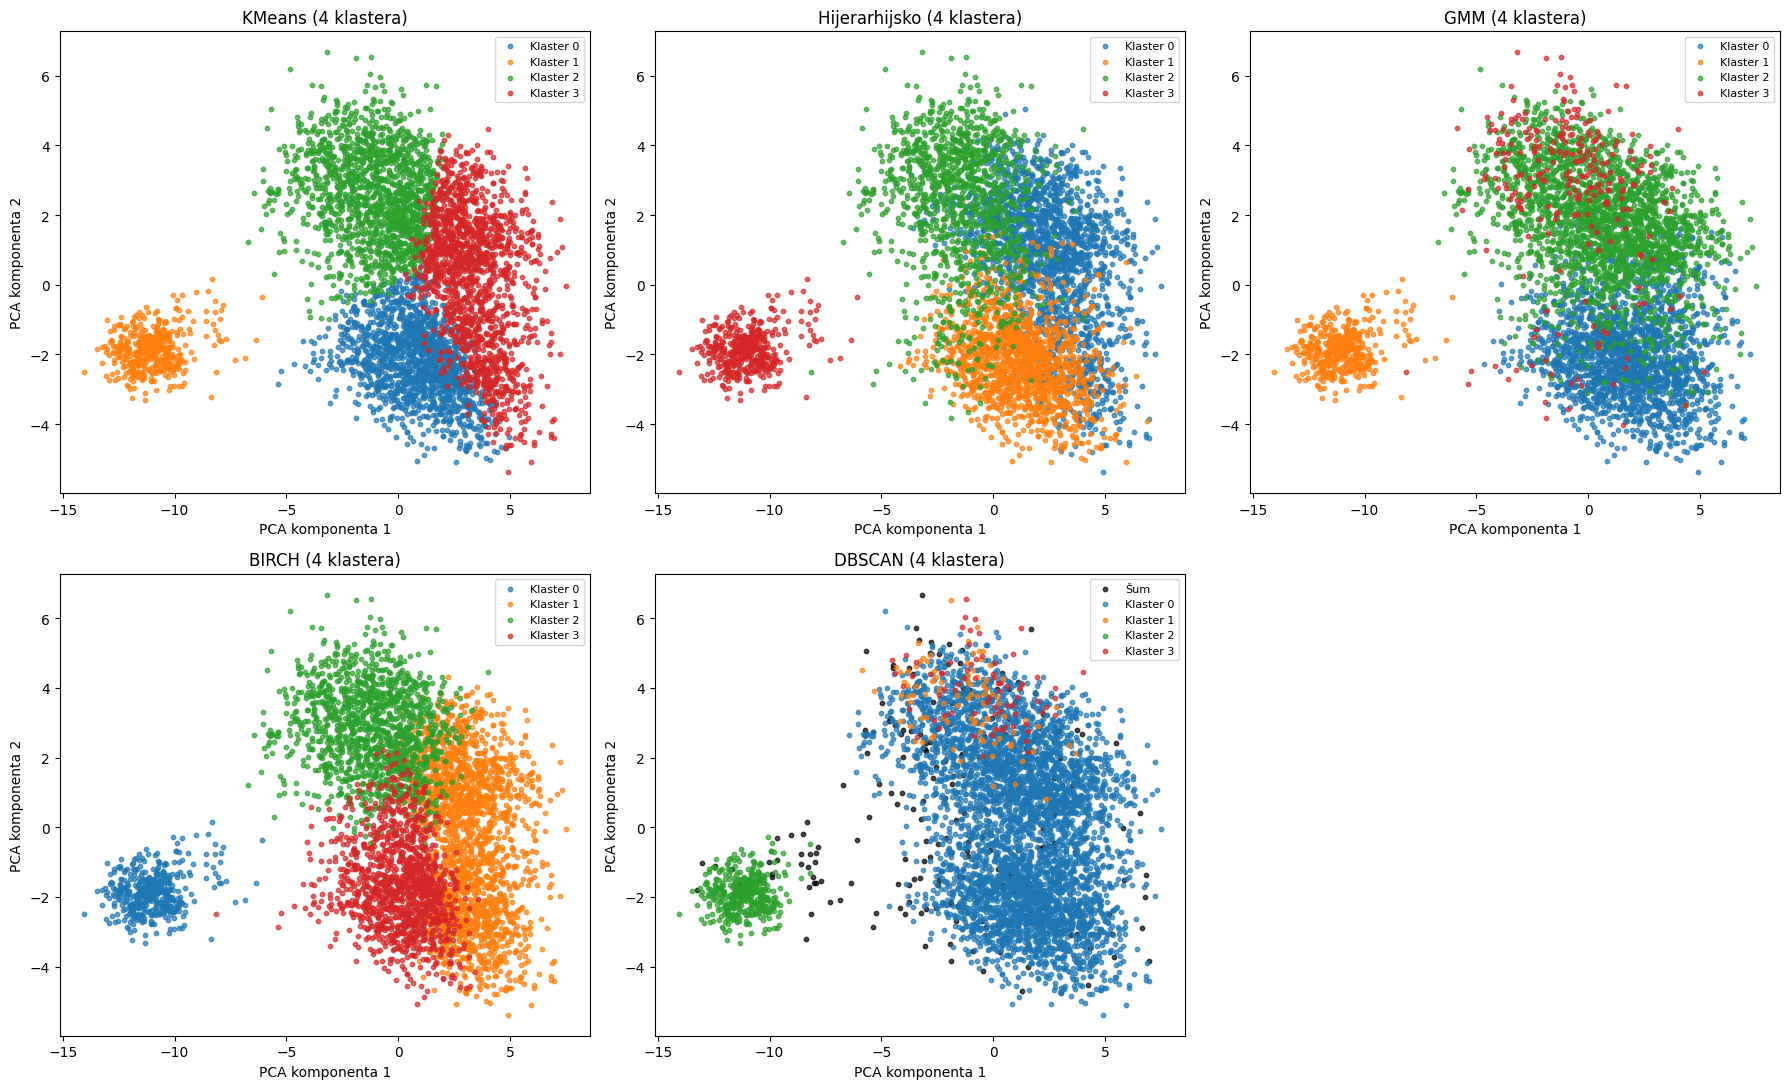

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

algorithms = [
    ("KMeans", labels_kmeans_vis),
    ("Hijerarhijsko", labels_hc_vis),
    ("GMM", labels_gmm_vis),
    ("BIRCH", labels_birch_vis),
    ("DBSCAN", labels_dbscan_vis),
]

for i, (name, labels) in enumerate(algorithms):
    unique_labels = np.unique(labels)

    for lab in unique_labels:
        mask = labels == lab

        if lab == -1:
            axes[i].scatter(
                X_vis_pca[mask, 0],
                X_vis_pca[mask, 1],
                s=10,
                c="black",
                alpha=0.7,
                label="Šum"
            )
        else:
            axes[i].scatter(
                X_vis_pca[mask, 0],
                X_vis_pca[mask, 1],
                s=10,
                alpha=0.7,
                label=f"Klaster {lab}"
            )

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    axes[i].set_title(f"{name} ({n_clusters} klastera)")
    axes[i].set_xlabel("PCA komponenta 1")
    axes[i].set_ylabel("PCA komponenta 2")
    axes[i].legend(fontsize=8)

# poslednji subplot je višak
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Objedinjeni prikaz svih pet algoritama nad identičnim uzorkom od 5000 igrača unutar istog dvodimenzionalnog PCA prostora omogućava direktno poređenje geometrijskih pretpostavki svakog modela:

* **KMeans i BIRCH** generišu izuzetno slične, oštro razgraničene particije. Oba algoritma stabilno izdvajaju golmane kao potpuno izolovano geometrijsko ostrvo, dok preostalu masu fudbalera u polju dele na tri kompaktne grupe. Ova podela se direktno i prirodno može mapirati na osnovne linije u timu: odbranu, vezni red i napad.
* **Hijerarhijsko klasterovanje** takođe uspešno izoluje golmane, ali preostale igrače u polju deli putem horizontalnih slojeva. Ovo ukazuje na to da algoritam drugačije interpretira gradijent gustine u centralnom delu prostora obeležja.
* **GMM (Gaussian Mixture Model)** prikazuje elipsoidne forme i značajno preklapanje grupa u centralnoj masi podataka. Ovakav pristup vizuelno najbolje oslikava postojanje "hibridnih" fudbalskih pozicija (poput krilnih bekova ili ofanzivnih veznih igrača) gde prelazi između uloga nisu strogo geometrijski ograničeni.
* **DBSCAN** demonstrira specifično ponašanje algoritama zasnovanih na gustini. On uspešno prepoznaje golmane kao homogeno i gusto jezgro (Klaster 2), dok sve igrače u polju ostavlja unutar jednog masivnog kontinuiranog skupa (Klaster 0). Svi igrači koji se nalaze na ekstremnim ivicama ili na praznom prelazu između golmana i terena ispravno su identifikovani kao šum (crne tačke). 

**Konačni zaključak i izbor modela:**
Iako DBSCAN pruža odličan uvid u prirodnu gustinu podataka i izdvaja autlajere, zadržavanje svih igrača u polju unutar samo jednog klastera narušava praktičnu primenljivost modela za diferencijaciju taktičkih uloga. 

Uzimajući u obzir prethodne numeričke metrike (gde KMeans ostvaruje ubedljivo najbolji Davies-Bouldin indeks od 1.74 i najvišu vrednost Calinski-Harabasz indeksa od 1497.30) i ovu vizuelnu stabilnost, **KMeans algoritam se usvaja kao konačno i optimalno rešenje**. Model uspešno rešava postavljen domenski problem: obezbeđuje visoku interpretabilnost i jasne, primenljive fudbalske uloge bez potrebe za odbacivanjem atipičnih igrača.

### Uticaj redukcije dimenzionalnosti na kvalitet klasterovanja

Za ispitivanje uticaja redukcije dimenzionalnosti na uspešnost grupisanja iskorišćen je algoritam K-sredina (KMeans) kao dokazano najstabilniji i najinterpretabilniji model u prethodnim koracima. Primenom metode glavnih komponenti (PCA) sa 10 ciljanih komponenti, vrši se kompresija prostora obeležja sa ciljem uklanjanja redundantnosti, smanjenja šuma i provere da li se u niže-dimenzionalnom prostoru postiže bolja separabilnost prirodnih grupa igrača.

In [69]:
pca_10 = PCA(n_components=10, random_state=19)
X_pca10 = pca_10.fit_transform(X_scaled)

In [70]:
print("Varijansa po komponentama:")
print(pca_10.explained_variance_ratio_)

print("Ukupno sačuvano:",
      pca_10.explained_variance_ratio_.sum())

Varijansa po komponentama:
[0.38350528 0.13983574 0.07641251 0.05045933 0.04760151 0.03713474
 0.0344219  0.02444485 0.02355945 0.02067623]
Ukupno sačuvano: 0.8380515306379429


In [71]:
kmeans_pca = KMeans(
    n_clusters=4,
    random_state=19,
    n_init=10
)

clusters_kmeans_pca = kmeans_pca.fit_predict(X_pca10)

In [72]:
X_pca10_eval = X_pca10[idx_eval]
labels_pca_eval = clusters_kmeans_pca[idx_eval]

In [73]:
print("KMeans + PCA(10)")
print("Silhouette:",
      silhouette_score(X_pca10_eval, labels_pca_eval))
print("Davies-Bouldin:",
      davies_bouldin_score(X_pca10_eval, labels_pca_eval))
print("Calinski-Harabasz:",
      calinski_harabasz_score(X_pca10_eval, labels_pca_eval))

KMeans + PCA(10)
Silhouette: 0.22652081243739303
Davies-Bouldin: 1.4485596200707294
Calinski-Harabasz: 2129.9255913435663


In [74]:
pca_vis = PCA(n_components=2, random_state=19)
X_pca10_vis = pca_vis.fit_transform(X_pca10)

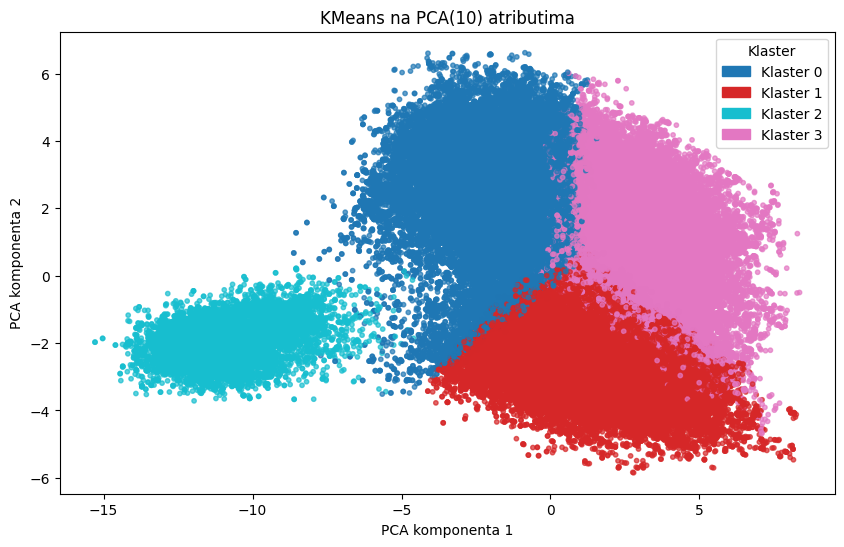

In [75]:
plt.figure(figsize=(10, 6))

colors = ['tab:blue', 'tab:red', 'tab:cyan', 'tab:pink']

plt.scatter(
    X_pca10_vis[:, 0],
    X_pca10_vis[:, 1],
    c=[colors[c] for c in clusters_kmeans_pca],
    s=10,
    alpha=0.7
)
plt.title("KMeans na PCA(10) atributima")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
patches = [mpatches.Patch(color=colors[i], label=f'Klaster {i}') for i in range(4)]
plt.legend(handles=patches, title="Klaster")
plt.show()

In [76]:
final_compare = pd.DataFrame({
    "Model": ["KMeans (svi atributi)", "KMeans + PCA(10)"],
    "Silhouette": [0.174894, 0.226521],  
    "Davies-Bouldin": [1.741409, 1.448560],  
    "Calinski-Harabasz": [1497.299749, 2129.925591]  
})

final_compare

,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans (svi atributi),0.174894,1.741409,1497.299749
1,KMeans + PCA(10),0.226521,1.448560,2129.925591


Analiza varijanse pokazuje da prvih 10 glavnih komponenti uspešno zadržava čak **83.81% ukupne varijanse** originalnog skupa podataka. Gubitak od oko 16% informacija je svestan i opravdan kompromis, jer je eliminisan matematički šum. 

Evaluacija na istom reprezentativnom uzorku pokazuje značajno poboljšanje kvaliteta klasterovanja po svim unutrašnjim metrikama:
* **Silhouette koeficijent** je porastao sa 0.174 na **0.226**, što ukazuje na znatno jasnije granice između klastera.
* **Davies-Bouldin indeks** je pao sa 1.741 na **1.448**, što potvrđuje da su klasteri postali zbijeniji, a međusobno udaljeniji.
* **Calinski-Harabasz score** beleži značajan porast sa 1497.30 na **2129.92**, demonstrirajući vrhunski odnos između unutar-klasterske zbijenosti i međuklasterske razdvojenosti.

Napominje se da su metrike za KMeans + PCA(10) računate u reduciranom prostoru 
od 10 komponenti, dok su metrike za originalni KMeans računate u punom prostoru 
od 42 atributa. Deo poboljšanja vrednosti metrika stoga može biti posledica 
promene prostora u kome se rastojanja mere, a ne isključivo poboljšanja kvaliteta 
klasterovanja.

Dobijeni rezultati pokazuju poboljšanje svih metrika kvaliteta klasterovanja u odnosu na originalni skup atributa, što ukazuje da redukcija dimenzionalnosti uklanja redundantnost i poboljšava separabilnost prirodnih grupa igrača.

In [77]:
df["KMeans_PCA10_cluster"] = clusters_kmeans_pca

cluster_profile = df.groupby("KMeans_PCA10_cluster")[
    [
        "overall_rating",
        "gk_diving",
        "standing_tackle",
        "short_passing",
        "finishing",
        "sprint_speed"
    ]
].mean().round(2)

cluster_profile

,overall_rating,gk_diving,standing_tackle,short_passing,finishing,sprint_speed
KMeans_PCA10_cluster,,,,,,
0,64.40,9.78,64.70,58.79,34.95,62.93
1,68.77,9.87,31.73,64.91,65.78,74.37
2,68.21,69.88,18.92,28.07,18.16,46.09
3,73.04,9.89,67.88,73.26,54.93,71.98


#### Semantička interpretacija i profilisanje klastera

Na osnovu prosečnih vrednosti ključnih fudbalskih atributa unutar identifikovanih grupa iz našeg konačnog i optimalnog modela (KMeans + PCA), izvršena je precizna verifikacija i profilisanje četiri klastera:

| Klaster | Tumačenje | Glavni atributi |
|---|---|---|
| Klaster 0 | Odbrambeni igrači | standing_tackle |
| Klaster 1 | Napadači i krilni igrači | finishing, sprint_speed |
| Klaster 2 | Golmani | gk_diving |
| Klaster 3 | Vezni igrači / Kreatori igre | short_passing, overall_rating |

* **Klaster 0 (Odbrambeni igrači):** Primarna karakteristika ove grupe je visok učinak u defanzivnim duelima i uspešna startovanja na loptu (`standing_tackle` = 64.70), uz nizak prosek tehnike završnice i postizanja golova.
* **Klaster 1 (Napadači i krilni igrači):** Ovu grupu odlikuje izrazita brzinska dominacija na terenu (`sprint_speed` = 74.37) i najviši prosek uspešnosti realizacije napada (`finishing` = 65.78), uz minimalan doprinos u odbrambenim zadacima.
* **Klaster 2 (Golmani):** Potpuno izolovan i specifičan klaster gde parametar `gk_diving` iznosi visokih 69.88, dok su sve ostale ocene koje se odnose na aktivnu igru u polju na svom statističkom minimumu.
* **Klaster 3 (Vezni igrači / Kreatori igre):** Fudbaleri unutar ove grupe poseduju najviši ukupni kvalitet (`overall_rating` = 73.04) i ubedljivo najbolju kontrolu poseda kroz kratka dodavanja (`short_passing` = 73.26), što dobro opisuje ulogu modernih veznih igrača i motora ekipe.

In [78]:
df.to_csv("player_attributes_clean.csv", index=False)

### Zaključak

U ovom radu uspešno je sproveden sveobuhvatan proces klasterovanja fudbalera na 
osnovu njihovih performansi iz baze podataka "Player_Attributes". Kroz rigorozan 
analitički postupak, testirano je pet različitih algoritama mašinskog učenja: 
KMeans, Hijerarhijsko klasterovanje, GMM, BIRCH i DBSCAN.

Primenom Elbow metode i analize Silhouette koeficijenta utvrđeno je da je optimalan 
broj klastera k=4. Ovaj broj se prirodno poklapa sa domenskim, fudbalskim znanjem 
i prirodnom podelom uloga na terenu (golmani, odbrana, vezni red i napad).

Tokom komparativne analize, algoritam K-sredina (KMeans) se izdvojio kao najpogodniji 
model, nudeći najbolji balans između metričke stabilnosti i praktične interpretabilnosti 
rezultata, za razliku od DBSCAN-a koji je formirao prevelike homogene celine i 
odbacivao prelazne igrače u šum.

Kao ključni korak unapređenja, redukcija dimenzionalnosti pomoću PCA sa 10 glavnih 
komponenti značajno je povećala separabilnost grupa eliminisanjem redundantnosti među 
atributima. Metrike su zabeležile poboljšanje, pri čemu napominjemo da su ove vrednosti računate u reduciranom prostoru 
od 10 komponenti, što delimično doprinosi njihovom poboljšanju u poređenju sa 
originalnim modelom evaluiranim u punom prostoru atributa. Ipak, dobijena podela 
potvrđuje da se u sažetom prostoru obeležja formiraju znatno čistiji i kompaktniji 
taktički profili igrača.

Očišćeni i strukturirani podaci sa pridruženim klasterima uspešno su sačuvani u datoteku player_attributes_clean.csv za dalju analizu i upotrebu.